In [ ]:
import kagglehub
https://www.kaggle.com/api/v1/datasets/download/prashant268/chest-xray-covid19-pneumonia?dataset_version_number=2
# Download latest version
path = kagglehub.dataset_download("prashant268/chest-xray-covid19-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.06G/2.06G [01:34<00:00, 23.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prashant268/chest-xray-covid19-pneumonia/versions/2


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os
import cv2
import numpy as np

data_path = "/root/.cache/kagglehub/datasets/prashant268/chest-xray-covid19-pneumonia/versions/2/Data"
save_path = "/content/processed_data"

for split in ["train", "test"]:
    for category in ["NORMAL", "PNEUMONIA"]:

        input_folder = os.path.join(data_path, split, category)
        output_folder = os.path.join(save_path, split, category)

        os.makedirs(output_folder, exist_ok=True)

        for file in os.listdir(input_folder):
            img_path = os.path.join(input_folder, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (224, 224))

            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(resized)

            save_file_path = os.path.join(output_folder, file)
            cv2.imwrite(save_file_path, enhanced)

print("All processed images saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/prashant268/chest-xray-covid19-pneumonia/versions/2/Data/train/NORMAL'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
train_dir = "/content/processed_data/train"
test_dir = "/content/processed_data/test"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 4684 images belonging to 2 classes.
Found 1172 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.3))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.4))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 83ms/step - accuracy: 0.7544 - loss: 0.6113
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9217 - loss: 0.1980
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9326 - loss: 0.1780
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9426 - loss: 0.1513
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9503 - loss: 0.1296
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9571 - loss: 0.1181
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.9593 - loss: 0.1046
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9586 - loss: 0.1063
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9678 - loss: 0.0889
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9706 - loss: 0.0773


In [ ]:
model.evaluate(test_generator)

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9692 - loss: 0.1155


[0.1350257247686386, 0.9564846158027649]

In [ ]:
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import cv2
import numpy as np

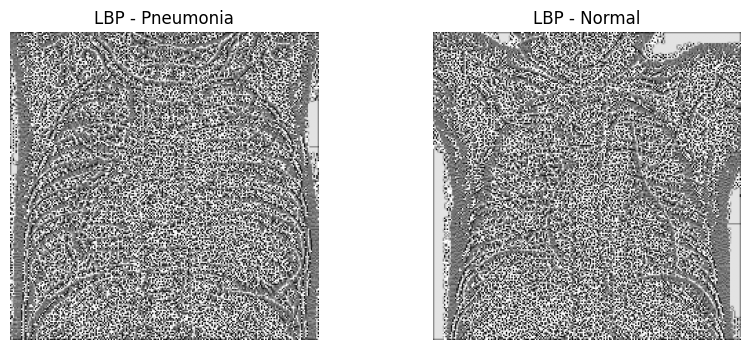

In [ ]:
# Load one pneumonia and one normal image
pneumonia_path = "/content/processed_data/test/PNEUMONIA/PNEUMONIA(3419).jpg"
normal_path = "/content/processed_data/test/NORMAL/NORMAL(1267).jpg"

img_p = cv2.imread(pneumonia_path)
img_n = cv2.imread(normal_path)

img_p = cv2.resize(img_p, (224,224))
img_n = cv2.resize(img_n, (224,224))

gray_p = cv2.cvtColor(img_p, cv2.COLOR_BGR2GRAY)
gray_n = cv2.cvtColor(img_n, cv2.COLOR_BGR2GRAY)

# LBP parameters
radius = 1
n_points = 8 * radius

lbp_p = local_binary_pattern(gray_p, n_points, radius, method="uniform")
lbp_n = local_binary_pattern(gray_n, n_points, radius, method="uniform")

# Display
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(lbp_p, cmap='gray')
plt.title("LBP - Pneumonia")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lbp_n, cmap='gray')
plt.title("LBP - Normal")
plt.axis("off")

plt.show()

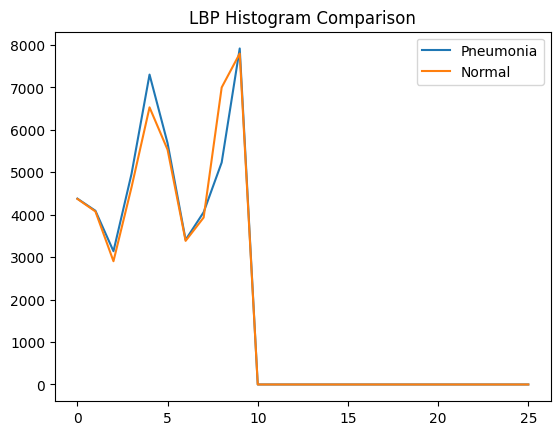

In [ ]:
# Histogram comparison
hist_p, _ = np.histogram(lbp_p.ravel(), bins=26, range=(0,26))
hist_n, _ = np.histogram(lbp_n.ravel(), bins=26, range=(0,26))

plt.plot(hist_p, label="Pneumonia")
plt.plot(hist_n, label="Normal")
plt.legend()
plt.title("LBP Histogram Comparison")
plt.show()

In [ ]:
radius = 1
n_points = 8 * radius
n_bins = n_points + 2   # for uniform LBP

In [ ]:
def extract_lbp_from_folder(folder_path):

    histograms = []

    for file in os.listdir(folder_path):

        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        lbp = local_binary_pattern(gray, n_points, radius, method="uniform")

        hist, _ = np.histogram(lbp.ravel(),
                               bins=n_bins,
                               range=(0, n_bins))

        # Normalize histogram
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        histograms.append(hist)

    # Return mean histogram of entire class
    return np.mean(histograms, axis=0)

In [ ]:
pneumonia_path = "/content/processed_data/test/NORMAL"
normal_path = "/content/processed_data/test/PNEUMONIA"

In [ ]:
normal_hist = extract_lbp_from_folder(normal_path)
pneumonia_hist = extract_lbp_from_folder(pneumonia_path)

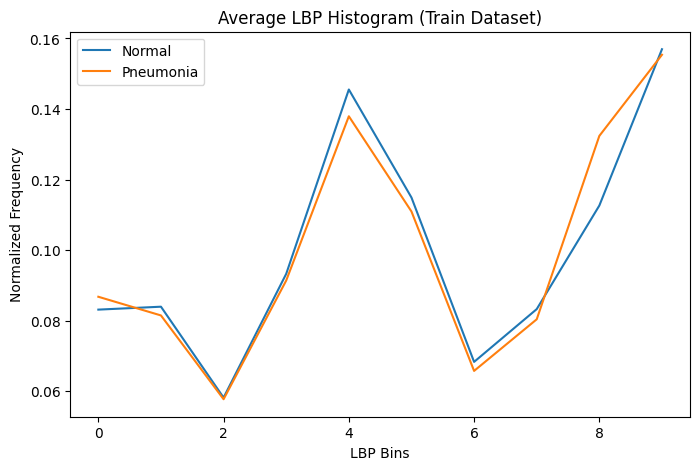

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(normal_hist, label="Normal")
plt.plot(pneumonia_hist, label="Pneumonia")

plt.xlabel("LBP Bins")
plt.ylabel("Normalized Frequency")
plt.title("Average LBP Histogram (Train Dataset)")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]

feature_model = Model(inputs=model.inputs,
                      outputs=layer_outputs)

In [ ]:
img = cv2.imread("/content/processed_data/test/PNEUMONIA/PNEUMONIA(3419).jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224,224))
img = img / 255.0

img = np.expand_dims(img, axis=-1)   # add channel dimension
img = np.expand_dims(img, axis=0)

In [ ]:
feature_maps = feature_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step


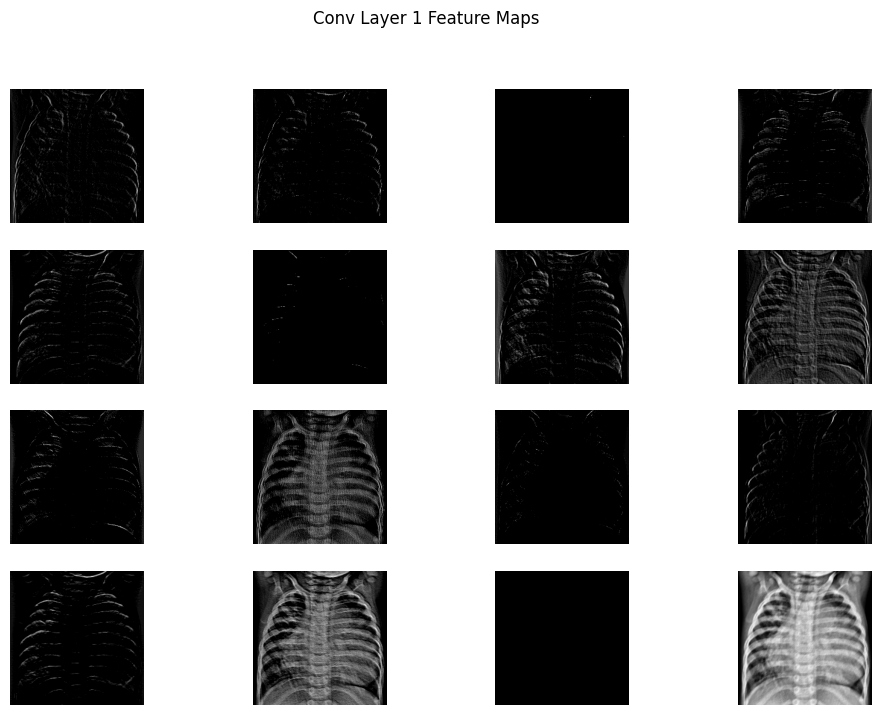

In [ ]:
plt.figure(figsize=(12,8))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0][0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Conv Layer 1 Feature Maps")
plt.show()

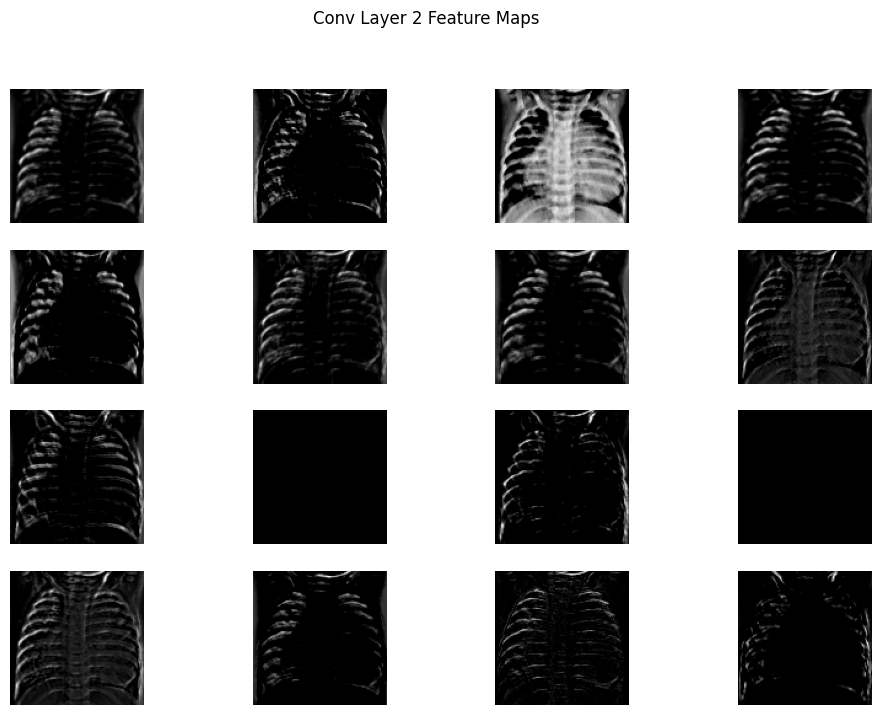

In [ ]:
plt.figure(figsize=(12,8))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[1][0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Conv Layer 2 Feature Maps")
plt.show()

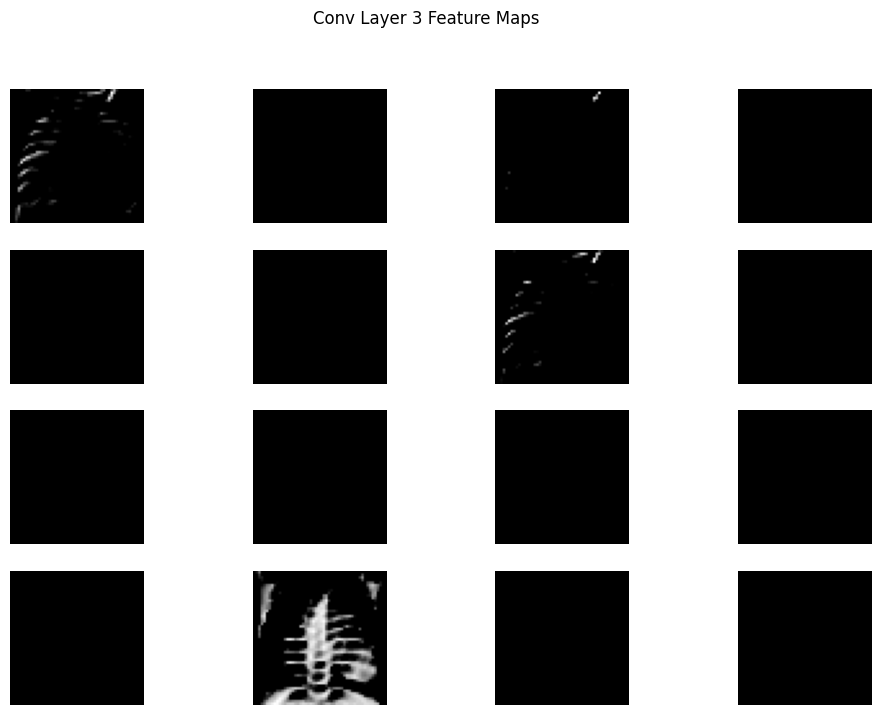

In [ ]:
plt.figure(figsize=(12,8))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[2][0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Conv Layer 3 Feature Maps")
plt.show()